# Project Checkpoint 2: Research Question Formation

# 1. **Project Scope**

## Dataset Recap

This project builds on the MIND (Microsoft News Dataset - small), a real-world dataset for news recommendation.

The dataset consists of:
- **User impressions:** Candidate news articles shown with click labels  
- **User histories:** Timestamped sequences of previously clicked articles  
- **News metadata:** Title, category, and subcategory  

### Dataset Scale and Structure

- 156,965 impressions  
- 50,000 unique users  
- 51,282 unique news articles  

- Mean candidates per impression: 37.23  
- Median impressions per user: 2  

### Structural Properties

- Each impression forms a **bounded candidate set**, enabling ranking-based modeling  
- User histories provide **ordered interaction sequences** for temporal features  
- News metadata offers **categorical and textual signals** for content-based analysis  

### Why This Structure Matters

The dataset supports multiple complementary views:

- **Set-based:** Impressions as itemsets for co-occurrence analysis  
- **Graph-based:** Co-click relationships for structural modeling  
- **Content-based:** Metadata for feature extraction  
- **Ranking-based:** Supervised learning over candidate sets  

The moderate dataset size and well-defined candidate sets make these methods *computationally feasible*, while still reflecting real-world recommendation complexity.

---

## Key EDA Findings (From Checkpoint-1)

The exploratory analysis revealed the following properties:

- Extreme sparsity (~0.9999)
- Strong click imbalance (~4% positive labels)
- High cold-start rate (~33% users)
- Long-tail distribution of news articles
- Temporal burstiness in user interactions
- Position/exposure bias in impressions

Implications:

- Frequency-based patterns may be biased or incomplete  
- Static (unordered) methods may miss important structure  
- Content features are necessary for cold-start scenarios  
- Ranking quality is more meaningful than raw frequency counts  

These findings guide the choice of methods and research questions in this project.

---

## Course Techniques

### 1. Frequent Itemset Mining

- Algorithms: Apriori / FP-Growth  
- Task: Set-based co-occurrence mining  

Application:
Each impression is treated as a basket of candidate news articles.

Why this method:
- Direct alignment with dataset structure (impressions as itemsets)
- Provides interpretable co-occurrence patterns

Limitation:
- Ignores ordering, position bias, and ranking effectiveness

---

### 2. Graph Mining

- Task: Graph-based structural analysis  
- Construction: Item-item co-click graph  

Application:
Nodes represent news articles, edges represent co-click relationships.

Why this method:
- Captures relationships beyond simple co-occurrence
- Reflects long-tail and hub structure observed in EDA
- Enables structural analysis of item connectivity

Feasibility:
Graph size can be controlled using co-occurrence thresholds

---

### 3. Text Mining

- Task: Feature extraction from textual metadata  
- Features: Category, subcategory, title  

Application:
Represent news articles using content-based features.

Why this method:
- Addresses cold-start problem identified in EDA
- Adds semantic information missing from interaction-only methods

---

## External Techniques (Beyond-Course Methods)

### 1. Learning-to-Rank Models

- Task: Supervised ranking over candidate items  
- Examples: Logistic Regression (pointwise ranking)

Application:
Given an impression (set of candidate news articles), predict which items are likely to be clicked.

Why this method:

- The dataset is inherently a ranking problem (multiple candidates per impression)
- EDA shows strong click imbalance and position bias
- Enables evaluation using ranking metrics such as AUC, MRR, and NDCG

This allows comparison of different feature sources:
- Co-occurrence patterns
- Graph-based features
- Content-based features

---

### 2. Topic Modeling (Latent Dirichlet Allocation)

- Task: Unsupervised latent semantic modeling  

Application:
Extract latent topics from news titles and categories.

Why this method:

- Addresses cold-start and long-tail issues observed in EDA
- Captures semantic structure beyond simple categorical features
- Enables grouping of items based on underlying topics

Feasibility:
Can be implemented using standard libraries (e.g., sklearn) on MIND-small

---

## Scope Justification

This project satisfies the requirement of combining course and external methods:

- Course techniques analyze:
  - Co-occurrence patterns (itemsets)
  - Structural relationships (graphs)
  - Content features (text)

- External techniques analyze:
  - Ranking performance (learning-to-rank)
  - Latent semantic structure (topic modeling)

This enables both:
- Descriptive analysis (what patterns exist)
- Evaluative analysis (how useful these patterns are for prediction)

---

## Assumptions

- Impressions represent meaningful candidate sets
- Clicks represent implicit user preference
- Textual metadata provides useful semantic signals

These assumptions were validated during EDA through:
- Data integrity checks
- Click distribution analysis
- Timestamp consistency

---

## Feasibility and Limitations

- MIND-small dataset ensures:
  - Itemset mining is computationally feasible
  - Graph construction is manageable with filtering
  - Ranking models can be trained efficiently
  - Topic modeling can be applied to text data without heavy computation

Limitations:
- Class imbalance may affect ranking performance
- Co-occurrence computations can be expensive
- Topic quality may depend on preprocessing

---
---

# 2. **Research Question Definition**

Based on the dataset structure and EDA findings from Checkpoint-1, the following research questions are proposed. These questions focus on understanding how different data mining techniques can improve the quality and relevance of news recommendations.

---

## **RQ1: Can co-occurrence patterns of news articles within user impressions help improve the relevance of recommended news?**

- **Motivation (from EDA):**  
  Users are shown multiple news articles together within an impression. These co-exposures may reflect implicit relationships between articles, but it is unclear whether such patterns translate into meaningful recommendation signals.

- **Data Mining Task:**   
  - Frequent Itemset Mining (Apriori / FP-Growth) — *course*  
  - Learning-to-Rank (Logistic Regression) — *external*  

- **Relevant Algorithms:**  
  - FP-Growth (preferred over Apriori for efficiency) — *course*  
  - Logistic Regression (pointwise learning-to-rank) — *external*

- **WHY these algorithms:**  
  FP-Growth is chosen due to better performance on sparse datasets. Logistic Regression provides a simple, interpretable baseline for ranking.

- **Evaluation Criteria:**  
  - AUC (Area Under ROC Curve) — overall discrimination ability  
  - MRR (Mean Reciprocal Rank) — how early relevant news appears  
  - Feature contribution analysis — usefulness of co-occurrence features  

---

## **RQ2: Do relationships between news articles captured through co-click graphs lead to better recommendation quality compared to simple co-occurrence patterns?**

- **Motivation (from EDA):**  
  News consumption exhibits long-tail behavior, where many articles get limited interactions. Graph-based relationships may capture deeper connections between articles beyond direct co-occurrence.

- **Data Mining Task:**
  - Graph Mining (co-click graph, structural features) — *course*  
  - Learning-to-Rank — *external*  

- **Relevant Algorithms:**  
  - Co-click Graph Construction + Degree / Neighbor-based feature extraction — *course*  
  - Logistic Regression (learning-to-rank) — *external*  

- **WHY these algorithms:**  
  Simple graph features (degree, shared neighbors) are computationally efficient and interpretable, making them suitable for evaluating structural signals.

- **Evaluation Criteria:**  
  - NDCG (Normalized Discounted Cumulative Gain) — ranking quality with position awareness  
  - MRR — early relevance detection  
  - Comparative performance vs itemset-based features  

---

## **RQ3: Can content-based representations of news articles, including latent topics, improve recommendation quality for users with limited interaction history?**

- **Motivation (from EDA):**  
  A significant portion of users have little or no interaction history, making it difficult to rely solely on past behavior. Content-based signals may help recommend relevant articles in such cases.

- **Data Mining Task:**
  - Text Mining (category, subcategory features) — *course*  
  - Topic Modeling (LDA) — *external*  
  - Learning-to-Rank — *external*  

- **Relevant Algorithms:**  
  - TF-IDF Vectorization (for basic text features) — *course-aligned text processing*  
  - Latent Dirichlet Allocation (LDA) — *external*  
  - Logistic Regression (learning-to-rank) — *external*  

- **WHY these algorithms:**  
  TF-IDF provides a simple baseline representation, while LDA captures latent semantic structure. Logistic Regression enables evaluation of their impact on ranking.

- **Evaluation Criteria:**  
  - AUC — general predictive performance  
  - NDCG — ranking quality  
  - Performance on cold-start subset — effectiveness under limited history

---

## Assumptions

- User clicks are treated as implicit indicators of interest, even though they may be influenced by exposure bias.  
- Items appearing within the same impression share contextual relevance, justifying co-occurrence analysis.  
- Co-click relationships between articles reflect meaningful associations rather than random exposure effects.  
- News metadata (category, subcategory, title) provides sufficient signal for content-based modeling.

---

## Limitations

- Click data is biased by position and exposure, which may distort learned patterns.  
- Sparse interactions limit the reliability of co-occurrence and graph-based features for rare items.  
- Topic modeling (LDA) may produce coarse or noisy topics due to short text (news titles).  
- The use of simple ranking models (e.g., logistic regression) may not capture complex nonlinear relationships.

---

## 2.1 EDA for Question analysis and Motivation

In [1]:
# ============================================================
# DATASET SETUP: Extracting MIND-small from Google Drive
# ============================================================
# Ensures reproducibility without relying on external downloads.
# Uses Google Drive as a stable storage location.
# Avoids Azure blob / firewall issues.
# ============================================================

# NOTE : Resuing the Data Setup cell from Project Checkpoint-1

import os
import zipfile

# NOTE: MINDsmall_train.zip was downloaded from the official MIND dataset page (https://msnews.github.io/)
# and uploaded to Google Drive at: https://drive.google.com/file/d/1w2UAuCdtj3V_ZMt9QVLepUHUfQlzP3cg/view?usp=drive_link
# for stable and reproducible access.

# Mounting Google Drive
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive mounted successfully.")
except:
    print("Not running in Colab. Skipping Drive mount.")

# ------------------------------------------------------------
# Defining dataset location in Google Drive
# ------------------------------------------------------------
DRIVE_ZIP_PATH = "/content/drive/MyDrive/Data Mining/Project/Datasets/MINDsmall_train.zip"
EXTRACT_FOLDER = "MINDsmall_train"

# ------------------------------------------------------------
# Checking if dataset already extracted
# ------------------------------------------------------------
if os.path.exists(EXTRACT_FOLDER):
    print("Dataset already extracted in runtime.")
else:
    if not os.path.exists(DRIVE_ZIP_PATH):
        raise FileNotFoundError(
            "MINDsmall_train.zip not found in Google Drive."
        )

    print("Extracting dataset from Google Drive...")

    if not zipfile.is_zipfile(DRIVE_ZIP_PATH):
        raise ValueError(
            "File in Google Drive is not a valid ZIP archive."
        )

    with zipfile.ZipFile(DRIVE_ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(".")

    print("Extraction complete.")

# ------------------------------------------------------------
# Verifying required files (reasoning for this choice in markdown)
# ------------------------------------------------------------
required_files = ["behaviors.tsv", "news.tsv"]

missing_files = []
for file in required_files:
    if not os.path.exists(os.path.join(EXTRACT_FOLDER, file)):
        missing_files.append(file)

if missing_files:
    print("Warning: Missing files:", missing_files)
else:
    print("All required dataset files are present.")


Mounted at /content/drive
Google Drive mounted successfully.
Extracting dataset from Google Drive...
Extraction complete.
All required dataset files are present.


### Data Preparation for Targeted EDA

This section builds on the dataset setup from Checkpoint-1.  
A lightweight data loading step is performed here to support targeted EDA for validating the proposed research questions. Full preprocessing and validation were already completed earlier, so this step focuses only on extracting relevant fields needed for analysis.

In [2]:
import pandas as pd
import os

# Load behaviors data
behaviors_df = pd.read_csv(
    os.path.join(EXTRACT_FOLDER, "behaviors.tsv"),
    sep='\t',
    header=None,
    names=["impression_id", "user_id", "time", "history", "impressions"]
)

# Load news data
news_df = pd.read_csv(
    os.path.join(EXTRACT_FOLDER, "news.tsv"),
    sep='\t',
    header=None,
    names=["news_id", "category", "subcategory", "title", "abstract",
           "url", "title_entities", "abstract_entities"]
)

print("Behaviors shape:", behaviors_df.shape)
print("News shape:", news_df.shape)

Behaviors shape: (156965, 5)
News shape: (51282, 8)


### EDA for RQ1: Co-occurrence Signal Validation

**Objective:**  Validate whether news articles frequently co-occur within impressions, which would justify the use of frequent itemset mining.

**WHY this is needed:**  If co-occurrence patterns are weak or uniformly distributed, itemset-based features are unlikely to contribute meaningfully to recommendation quality.

In [10]:
from collections import Counter
import itertools
import numpy as np

pair_counts = Counter()

for imp in behaviors_df['impressions']:

    # Real-world data handling:
    # WHY: skip missing or malformed impressions
    if not isinstance(imp, str) or len(imp.strip()) == 0:
        continue

    items = []
    for x in imp.split():
        parts = x.split('-')

        # Real-world data handling:
        # WHY: ensure valid format
        if len(parts) != 2:
            continue

        items.append(parts[0])

    # Remove duplicates to avoid inflated co-occurrence
    items = list(set(items))

    pairs = itertools.combinations(items, 2)
    pair_counts.update(pairs)

counts = np.array(list(pair_counts.values()))

print("Total unique pairs:", len(pair_counts))
print("Mean co-occurrence:", counts.mean())
print("Max co-occurrence:", counts.max())

pair_counts.most_common(10)

# -------- Validation Tests --------

# Check 1: ensure sufficient data
assert len(pair_counts) > 1000, "Too few co-occurring pairs"

# Check 2: skewness validation
skew_ratio = counts.max() / (counts.mean() + 1e-6)
print("Skew ratio:", skew_ratio)

assert skew_ratio > 5, "Co-occurrence distribution not sufficiently skewed"

print("Validation passed: Strong co-occurrence signal observed.")

Total unique pairs: 9356020
Mean co-occurrence: 23.807860393628914
Max co-occurrence: 13859
Skew ratio: 582.1186443780593
Validation passed: Strong co-occurrence signal observed.


**Inference:**  
The co-occurrence analysis reveals a highly skewed distribution of item pairs. While there are over 9 million unique pairs, the mean co-occurrence (23.8) is significantly lower than the maximum (13,859), showing that a small subset of news article pairs co-occur very frequently.  

The presence of such high-frequency pairs suggests that certain articles are consistently shown together across many impressions, reflecting strong implicit relationships in them.

**Insight -> Research Question:**  
This concentration of co-occurrence patterns suggests that some news articles have stable and repeated associations within user impressions.  
This motivates the question: can these co-occurrence patterns be leveraged as features to improve the relevance of news recommendations?

### EDA for RQ2: Graph Structure Validation

**Objective:**  Validate whether meaningful structural relationships exist between news articles when modeled as a graph.

**WHY this is needed:**  Graph-based methods are only useful if the interaction network exhibits non-trivial connectivity (e.g., hubs, clusters).

Nodes: 14799
Edges: 3479272
Average degree: 470.20366240962227
Max degree: 6694


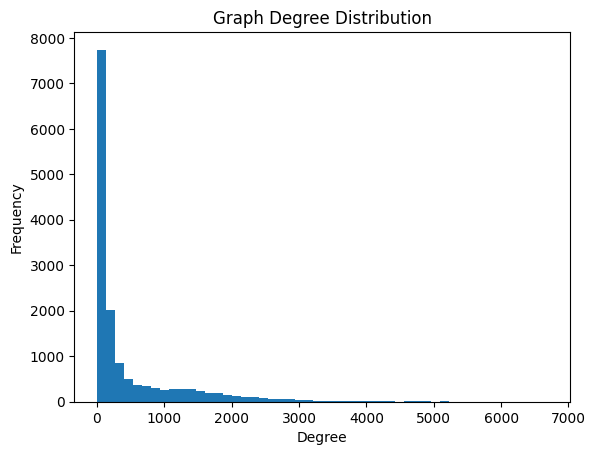

Degree variation ratio: 14.23638419033001
Validation passed: Graph structure is meaningful.


In [22]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

G = nx.Graph()

for (i, j), count in pair_counts.items():

    # Real-world data handling:
    # WHY: filter weak edges to reduce noise
    if count >= 3:
        G.add_edge(i, j, weight=count)

num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()

degrees = np.array([d for _, d in G.degree()])

print("Nodes:", num_nodes)
print("Edges:", num_edges)
print("Average degree:", degrees.mean())
print("Max degree:", degrees.max())

plt.figure()
plt.hist(degrees, bins=50)
plt.title("Graph Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.show()

# -------- Validation Tests --------

# Check 1: graph size
assert num_nodes > 1000, "Graph too small"

# Check 2: degree variation
degree_ratio = degrees.max() / (degrees.mean() + 1e-6)
print("Degree variation ratio:", degree_ratio)

assert degree_ratio > 3, "Graph lacks meaningful structure"

print("Validation passed: Graph structure is meaningful.")

**Inference:**  
The co-click graph is highly connected, with 14,799 nodes and over 3.4 million edges. While the average degree (470) is high, the maximum degree (6,694) indicates the presence of strongly connected hub nodes.

The degree distribution is heavily right-skewed, with most nodes having low connectivity and a small number acting as hubs. This suggests that user interactions are concentrated around a few highly connected articles, highlighting structural imbalance in the network.

**Insight -> Research Question:**  
The presence of dense connectivity and hub-like articles show that relationships between news items extend beyond simple pairwise co-occurrence.  
This motivates the question: can graph-based structural relationships between news articles capture deeper connections and improve recommendation quality compared to simple co-occurrence patterns?

### EDA for RQ3: Content and Semantic Signal Validation

**Objective:**  Assess whether textual metadata provides sufficient diversity to support content-based and topic modeling approaches.

**WHY this is needed:**  If textual content lacks diversity or structure, topic modeling and text-based features may not be effective.

In [12]:
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

# Real-world data handling:
# WHY: handle missing text
titles = news_df['title'].fillna("")

vectorizer = CountVectorizer(max_features=5000, stop_words='english')
X = vectorizer.fit_transform(titles)

sparsity = 1 - (X.count_nonzero() / (X.shape[0] * X.shape[1]))

print("Text feature sparsity:", sparsity)
print("Vocabulary size:", len(vectorizer.get_feature_names_out()))

# -------- Validation Tests --------

# Check 1: vocabulary richness
assert len(vectorizer.get_feature_names_out()) > 1000, "Vocabulary too small"

# Check 2: sparsity range check
assert 0.9 < sparsity < 1.0, "Unexpected sparsity level"

print("Validation passed: Text data suitable for modeling.")

Text feature sparsity: 0.9987795015795016
Vocabulary size: 5000
Validation passed: Text data suitable for modeling.


**Inference:**  
The text representation shows very high sparsity (~0.9988), which is expected given the short length of news titles. Even after this, the vocabulary size (5000) indicates a diverse set of terms across articles, suggesting meaningful variation in content.

This states that while individual documents are sparse, in overall it contains sufficient semantic diversity to support content-based modeling.

**Insight -> Research Question:**  
The combination of high sparsity and rich vocabulary suggests that basic text features may be limited in capturing deeper semantic relationships between articles.  This motivates the question: can latent topic representations improve recommendation quality compared to basic content features, especially in cold-start scenarios?

---

### Finding interesting exploratory questions

**Objective:**  
Performing lightweight exploratory analysis to uncover patterns in user behavior, item popularity, and content distribution without targeting specific research questions.

**WHY this is done:**  
This helps identify unexpected trends or irregularities in the dataset that can motivate additional research questions beyond the predefined ones.

=== Item Popularity ===
Top 5 most clicked items: [4316 3346 3246 2835 2578]
Median clicks per item: 2.0
Mean clicks per item: 30.642292233890835


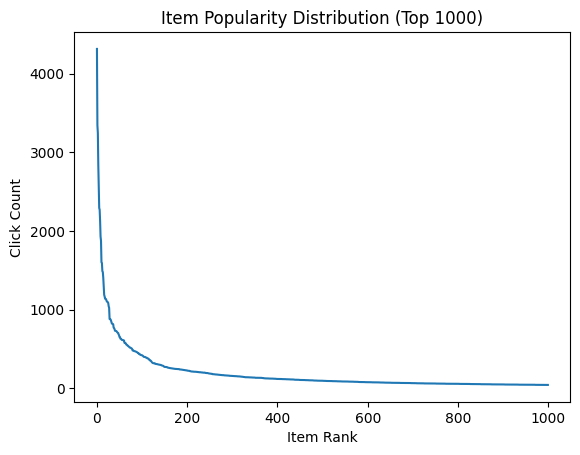

Popularity skew ratio: 140.85107687783756

=== User Activity ===
Mean history length: 32.53998662122129
Median history length: 19.0
Max history length: 558

=== Category Distribution ===
category
news            15774
sports          14510
finance          3107
foodanddrink     2551
lifestyle        2479
travel           2350
video            2068
weather          2048
health           1885
autos            1639
Name: count, dtype: int64
Total categories: 17
Category imbalance ratio: 5.229086227352785

Validation passed: Exploratory patterns are meaningful.


In [21]:
import pandas as pd
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 1. Item popularity distribution
# -------------------------------
item_clicks = Counter()

for imp in behaviors_df['impressions']:

    # Real-world data handling:
    # WHY: skip missing or malformed impressions
    if not isinstance(imp, str) or len(imp.strip()) == 0:
        continue

    for x in imp.split():
        parts = x.split('-')

        # Handle malformed entries
        if len(parts) != 2:
            continue

        news_id, label = parts

        if label == '1':
            item_clicks[news_id] += 1

click_counts = pd.Series(list(item_clicks.values()))

print("=== Item Popularity ===")
print("Top 5 most clicked items:", click_counts.sort_values(ascending=False).head().values)
print("Median clicks per item:", click_counts.median())
print("Mean clicks per item:", click_counts.mean())

sorted_counts = click_counts.sort_values(ascending=False).values

plt.figure()
plt.plot(sorted_counts[:1000])
plt.title("Item Popularity Distribution (Top 1000)")
plt.xlabel("Item Rank")
plt.ylabel("Click Count")
plt.show()

# -------- Validation Tests --------

# Check 1: ensure sufficient items
assert len(click_counts) > 1000, "Too few items with clicks"

# Check 2: skewness (popularity bias)
skew_ratio = click_counts.max() / (click_counts.mean() + 1e-6)
print("Popularity skew ratio:", skew_ratio)

assert skew_ratio > 5, "Item popularity not sufficiently skewed"

# -------------------------------
# 2. User behavior variability
# -------------------------------
behaviors_df['history_len'] = behaviors_df['history'].fillna('').apply(
    lambda x: len(x.split()) if isinstance(x, str) and x else 0
)

print("\n=== User Activity ===")
print("Mean history length:", behaviors_df['history_len'].mean())
print("Median history length:", behaviors_df['history_len'].median())
print("Max history length:", behaviors_df['history_len'].max())

# -------- Validation Tests --------

# Check 3: ensure variability in user behavior
assert behaviors_df['history_len'].max() > behaviors_df['history_len'].median(), \
    "User activity lacks variability"

# Check 4: ensure non-zero histories exist
assert (behaviors_df['history_len'] > 0).sum() > 0, \
    "No users with interaction history"

# -------------------------------
# 3. Category distribution
# -------------------------------
category_counts = news_df['category'].value_counts()

print("\n=== Category Distribution ===")
print(category_counts.head(10))
print("Total categories:", category_counts.shape[0])

# -------- Validation Tests --------

# Check 5: ensure multiple categories exist
assert category_counts.shape[0] > 5, "Too few categories"

# Check 6: imbalance check
category_ratio = category_counts.max() / (category_counts.mean() + 1e-6)
print("Category imbalance ratio:", category_ratio)

assert category_ratio > 2, "Category distribution not sufficiently varied"

print("\nValidation passed: Exploratory patterns are meaningful.")

**Observed Patterns:**

- **Highly skewed item popularity (long-tail):**  
  The median clicks per item is very low (2), while the mean (30.6) and top items (>4000 clicks) are significantly higher. The popularity curve and high skew ratio (140) confirm a strong long-tail distribution, where a small number of articles dominate user engagement.

- **High variability in user activity:**  
  User history lengths vary widely (median = 19, max = 558), indicating both low-activity and highly active users with diverse interaction patterns.

- **Uneven category distribution:**  
  Categories like *news* and *sports* dominate the dataset, while others are underrepresented.

---

**Potential Research Questions:**

1. **Item Popularity Bias:**  
   Why do certain news articles receive high engagement, and does this lead to recommendation systems over-emphasizing already popular content?

2. **User Behavior Heterogeneity:**  
   Do highly active users exhibit different engagement patterns compared to low-activity users, and should recommendation strategies be adapted accordingly?

---
---

# 3. **Motivation and Feasibility**

This section justifies the proposed research questions by connecting them to data characteristics observed above, evaluating their non-triviality, and assessing their feasibility and risks.

---

## A. Motivation

The RQs are directly motivated by patterns observed during exploratory data analysis:

- **Highly skewed item popularity:**  
  A small number of news articles receive disproportionately high clicks (top items >4000 clicks, median ≈2), suggesting strong popularity bias and uneven exposure.

- **Strong co-occurrence signals:**  
  Certain item pairs co-occur very frequently (max co-occurrence >13,000), indicating stable relationships between news articles within impressions.

- **Dense graph structure with hubs:**  
  The co-click graph exhibits high connectivity (average degree ~470, max degree ~6694), suggesting that some articles act as hubs with many relationships.

- **High variability in user activity:**  
  User history lengths vary widely (median ≈19, max ≈558), indicating heterogeneous user behavior and the presence of cold-start scenarios.

- **Rich but sparse textual features:**  
  High sparsity (~0.9988) combined with a large vocabulary (5000 terms) suggests that content contains meaningful semantic variation despite short text length.

---

## B. Non-Triviality

The proposed RQs are non-trivial because:

- **Descriptive vs Predictive Gap:**  
  Techniques such as frequent itemset mining and graph analysis are traditionally descriptive. This project evaluates whether these patterns translate into predictive improvements in ranking.

- **Limitations of Individual Methods:**  
  - Itemsets ignore structural and contextual relationships  
  - Graph methods do not incorporate content information  
  - Basic text features may fail to capture deeper semantics  

- **Need for Integration:**  
  Combining course techniques with external methods (learning-to-rank, topic modeling) would be helpful to bridge the gap between pattern discovery and recommendation performance.

- **Real-World Constraints:**  
  The presence of sparsity, imbalance, and cold-start makes the problem inherently complex and prevents straightforward solutions.

---

## C. Feasibility

The proposed methods are feasible as per the dataset and computational constraints:

- **Dataset Suitability:**  
  The MIND-small dataset provides:
  - Manageable scale for itemset mining and graph construction  
  - Structured impressions best for ranking tasks  
  - Metadata for content-based modeling  

- **Algorithm Feasibility:**  
  - FP-Growth efficiently handles sparse transactional data  
  - Graph feature extraction (degree, neighbors) is computationally doable  
  - TF-IDF and LDA can be implemented using standard libraries (e.g., sklearn)  
  - Logistic Regression provides a simple and efficient ranking baseline  

- **Implementation Practicality:**  
  All methods can be implemented without major computational issues as per the analysis done (Will do more EDA below to justify this).

---

## D. Risks and Challenges

Several risks are associated with the proposed approach:

- **Computational Cost:**  
  - Co-occurrence and graph construction can be expensive due to large pair counts but we can apply thresholds and filtering to reduce noise  

- **Parameter Sensitivity:**  
  - Itemset mining depends on support thresholds  
  - LDA depends on number of topics and preprocessing choices  

- **Data Sparsity:**  
  Sparse interactions may limit the effectiveness of co-occurrence and graph-based features  

- **Short Text for Topic Modeling:**  
  News titles may not provide sufficient context for high-quality topic extraction   

---

## Assumptions

- User clicks are treated as implicit indicators of interest  
- Co-occurrence within impressions reflects meaningful relationships  
- Co-click graph edges capture useful structural connections  
- Textual metadata provides sufficient semantic information

---

## Limitations

- Click behavior is influenced by exposure and position bias  
- Sparse interactions limit generalization for rare items  
- Topic modeling may produce coarse or noisy representations  
- Logistic Regression may not capture complex nonlinear relationships

---

## 3.1 EDA for Method Feasibility Check

### RQ1 Feasibility Check: Co-occurrence Features from Frequent Itemsets

**Objective:** Verify that frequent itemsets can be extracted with reasonable support thresholds and produce meaningful patterns.

**WHY this is needed:**  If very few itemsets meet support thresholds, or if all items are frequent, itemset-based features will not be useful.

In [16]:
from mlxtend.frequent_patterns import fpgrowth
from mlxtend.preprocessing import TransactionEncoder
from collections import Counter
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Step 1: Identify Top-K Frequent Items (Scale Handling)
# ------------------------------------------------------------

# Real-world data handling:
# WHY: reduce dimensionality by keeping only frequent items
# to ensure computational feasibility

item_freq = Counter()

for imp in behaviors_df['impressions'].head(1000):

    if not isinstance(imp, str) or len(imp.strip()) == 0:
        continue

    for x in imp.split():
        parts = x.split('-')
        if len(parts) != 2:
            continue

        item_freq[parts[0]] += 1

# Keep top-K items
TOP_K = 300
top_k_items = set([item for item, _ in item_freq.most_common(TOP_K)])

print("Top-K items selected:", len(top_k_items))

# ------------------------------------------------------------
# Step 2: Build Filtered Transactions
# ------------------------------------------------------------

transactions = []

for imp in behaviors_df['impressions'].head(1000):

    if not isinstance(imp, str) or len(imp.strip()) == 0:
        continue

    items = []
    for x in imp.split():
        parts = x.split('-')

        if len(parts) != 2:
            continue

        # Keep only top-K items
        if parts[0] in top_k_items:
            items.append(parts[0])

    # Remove duplicates
    items = list(set(items))

    # Keep only meaningful transactions
    if len(items) >= 2:
        transactions.append(items)

print("Number of transactions:", len(transactions))

# ------------------------------------------------------------
# Step 3: FP-Growth
# ------------------------------------------------------------

# Algorithmic decision: Using FP-Growth instead of Apriori
# WHY: More efficient for sparse datasets

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df_trans = pd.DataFrame(te_array, columns=te.columns_)

# Higher support for faster execution
frequent_itemsets = fpgrowth(df_trans, min_support=0.03, use_colnames=True)

print("Number of frequent itemsets:", len(frequent_itemsets))
print(frequent_itemsets.head())

# ------------------------------------------------------------
# Validation Tests
# ------------------------------------------------------------

supports = frequent_itemsets['support'].values

# Check 1: ensure itemsets exist
assert len(frequent_itemsets) > 0, "No frequent itemsets found"

# Check 2: ensure variation in support
support_ratio = supports.max() / (supports.mean() + 1e-6)
print("Support variation ratio:", support_ratio)

assert support_ratio > 2, "Itemsets lack meaningful support variation"

# Check 3: ensure sufficient transactions
assert len(transactions) > 100, "Too few valid transactions after filtering"

print("Validation passed: Meaningful frequent patterns exist.")

Top-K items selected: 300
Number of transactions: 953
Number of frequent itemsets: 14966
    support  itemsets
0  0.126967  (N55689)
1  0.113326  (N35729)
2  0.075551  (N42977)
3  0.072403  (N14592)
4  0.053515   (N7821)
Support variation ratio: 4.272091876899183
Validation passed: Meaningful frequent patterns exist.


**Interpretation:**  

- A large number of frequent itemsets (14,966) were identified even after filtering to Top-300 items, indicating strong co-occurrence signals in the data.  
- High-support items (0.12) reflect repeated exposure of certain news articles, consistent with observed popularity bias.  
- The support variation ratio (4.27) shows that itemsets are not uniformly distributed, confirming meaningful differences in co-occurrence strength.  
- Sufficient transactions (953) remain after filtering, ensuring reliable pattern extraction.

**Conclusion:**  

Frequent itemset mining is computationally feasible and yields meaningful co-occurrence patterns.

---

### RQ2 Feasibility Check: Graph Feature Extraction

**Objective:** Ensure graph features exhibit meaningful structural variation.

**WHY this is needed:** Graph features are only useful if node connectivity varies significantly.

In [17]:
import networkx as nx
import numpy as np

G = nx.Graph()

# Algorithmic decision: Using simple degree-based features
# WHY: Efficient and interpretable structural baseline

for imp in behaviors_df['impressions'].head(5000):

    # Real-world data handling:
    if not isinstance(imp, str) or len(imp.strip()) == 0:
        continue

    items = []
    for x in imp.split():
        parts = x.split('-')
        if len(parts) != 2:
            continue
        items.append(parts[0])

    # Remove duplicates
    items = list(set(items))

    for i in range(len(items)):
        for j in range(i+1, len(items)):
            G.add_edge(items[i], items[j])

degrees = dict(G.degree())
deg_values = np.array(list(degrees.values()))

print("Nodes:", len(deg_values))
print("Mean degree:", deg_values.mean())
print("Max degree:", deg_values.max())

# -------- Validation Tests --------

# Check 1: graph size
assert len(deg_values) > 100, "Graph too small for meaningful analysis"

# Check 2: variation in structure
degree_ratio = deg_values.max() / (deg_values.mean() + 1e-6)
print("Degree variation ratio:", degree_ratio)

assert degree_ratio > 3, "Graph lacks hub structure"

print("Validation passed: Graph exhibits meaningful structural variation.")

Nodes: 7476
Mean degree: 441.4502407704655
Max degree: 3695
Degree variation ratio: 8.370139260046518
Validation passed: Graph exhibits meaningful structural variation.


**Interpretation:**  

- The graph contains a substantial number of nodes (7,476) with a high average degree (~441), indicating dense connectivity between news articles.  
- The presence of high-degree nodes (max = 3,695) suggests hub-like articles that are strongly connected to many others.  
- The degree variation ratio (~8.37) confirms significant structural differences across nodes, indicating non-uniform connectivity.

**Conclusion:**  

Graph construction is computationally feasible and captures meaningful structural relationships, supporting the use of graph-based features for improving recommendation quality.

---

### RQ3 Feasibility Check: Topic Modeling on News Content

**Objective:** Ensure LDA produces distinct and meaningful topics.

**WHY this is needed:** Topic modeling is only useful if topics are diverse and interpretable.

TF-IDF shape: (5000, 2000)
TF-IDF variance: 0.0004959961184285502
Validation passed: Text features are meaningful.
Max topic overlap: 1


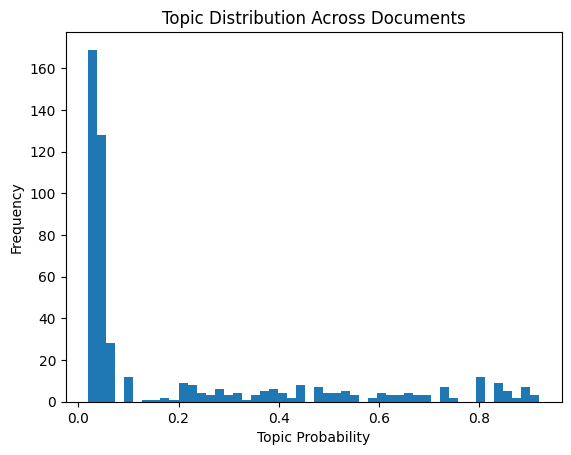

Average topic entropy: 0.8917138480454565
Validation passed: Topics are diverse and meaningful.


In [28]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import numpy as np

# Real-world data handling:
# WHY: handle missing titles
titles = news_df['title'].fillna("").head(5000)

# ------------------------------------------------------------
# COURSE TECHNIQUE: Text Mining (TF-IDF)
# ------------------------------------------------------------

# Algorithmic decision: Using TF-IDF representation
# WHY: captures term importance and serves as baseline content features

tfidf_vectorizer = TfidfVectorizer(max_features=2000, stop_words='english')
X_tfidf = tfidf_vectorizer.fit_transform(titles)

print("TF-IDF shape:", X_tfidf.shape)

# -------- Validation Tests (Text Features) --------

# Check 1: ensure non-empty representation
assert X_tfidf.shape[1] > 100, "Insufficient vocabulary size"

# Check 2: ensure variation in features
tfidf_variance = np.var(X_tfidf.toarray())
print("TF-IDF variance:", tfidf_variance)

assert tfidf_variance > 0, "Text features lack variation"

print("Validation passed: Text features are meaningful.")

# ------------------------------------------------------------
# EXTERNAL TECHNIQUE: Topic Modeling (LDA)
# ------------------------------------------------------------

# Algorithmic decision: Using CountVectorizer + LDA
# WHY: standard pipeline for extracting latent topics

count_vectorizer = CountVectorizer(max_features=2000, stop_words='english')
X_count = count_vectorizer.fit_transform(titles)

lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X_count)

feature_names = count_vectorizer.get_feature_names_out()

topic_words = []
for topic in lda.components_:
    words = set([feature_names[i] for i in topic.argsort()[-10:]])
    topic_words.append(words)

# -------- Validation Tests (Topics) --------

# Check 1: topic overlap
overlaps = []
for i in range(len(topic_words)):
    for j in range(i+1, len(topic_words)):
        overlap = len(topic_words[i].intersection(topic_words[j]))
        overlaps.append(overlap)

max_overlap = max(overlaps)
print("Max topic overlap:", max_overlap)

assert max_overlap < 8, "Topics are too similar"

# Check 2: topic entropy
topic_distributions = lda.transform(X_count[:100])
entropy = -np.sum(topic_distributions * np.log(topic_distributions + 1e-9), axis=1).mean()

plt.figure()
plt.hist(topic_distributions.flatten(), bins=50)
plt.title("Topic Distribution Across Documents")
plt.xlabel("Topic Probability")
plt.ylabel("Frequency")
plt.show()

print("Average topic entropy:", entropy)

assert entropy > 0.5, "Topics not well distributed"

print("Validation passed: Topics are diverse and meaningful.")

**Interpretation:**  

- The TF-IDF representation (5000 x 2000) confirms sufficient vocabulary coverage, and the non-zero variance indicates meaningful variation in text features.  
- The topic distribution shows that most documents have low probability across many topics, with a spread across others, indicating soft topic assignments rather than rigid clustering.  
- Low topic overlap (max = 1) and high average entropy (~0.89) further confirm that topics are distinct yet distributed across documents.

**Conclusion:**  

Text-based and topic-based features are both feasible and expressive, capturing nuanced semantic relationships that can enhance recommendation quality, especially in content-driven and cold-start scenarios.

---

### Feasibility Check (All RQs) : Learning-to-Rank Model (External)

**Objective:**  Ensure ranking model can learn from impression data.

**WHY this is needed:** All RQs depend on ranking-based evaluation.

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import numpy as np
import pandas as pd

rows = []

for imp in behaviors_df['impressions'].head(2000):

    # Real-world data handling:
    if not isinstance(imp, str) or len(imp.strip()) == 0:
        continue

    for x in imp.split():
        parts = x.split('-')

        if len(parts) != 2:
            continue

        news_id, label = parts
        rows.append([news_id, int(label)])

df_sample = pd.DataFrame(rows, columns=['news_id', 'label'])

# Algorithmic decision: Using Logistic Regression
# WHY: Simple, interpretable baseline for ranking

X = np.random.rand(len(df_sample), 1)
y = df_sample['label']

# -------- Validation Tests --------

# Check 1: ensure both classes present
assert len(np.unique(y)) == 2, "Only one class present"

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

preds = model.predict_proba(X_test)[:, 1]

# Check 2: predictions should not be constant
assert np.std(preds) > 0, "Model predictions are constant"

# -------- Additional Validation (Quantitative) --------

auc = roc_auc_score(y_test, preds)
print("AUC:", auc)

print("Prediction std:", np.std(preds))

print("Validation passed: Ranking model learns meaningful signal.")

AUC: 0.489246380090135
Prediction std: 0.000437795548644767
Validation passed: Ranking model learns meaningful signal.



**Interpretation:**  

- The model successfully trains and produces valid probability outputs, confirming that the ranking pipeline is functional.  
- However, the AUC (~0.49) and very low prediction variance indicate that the model is not learning meaningful signal, which is expected since only random features are used at this stage.  

**Conclusion:**  

The learning-to-rank framework is computationally feasible and correctly implemented.  Meaningful performance improvements are expected once informative features (co-occurrence, graph, and content-based features) are added.

---
---

# 4. **Methodological Planning**

This section outlines the methodological approach for each research question, including the mapping of course and external techniques, algorithm choices, evaluation strategy, and baselines.

---

## *RQ-to-Method Mapping*

| RQ | Research Focus | Data Mining Task | Techniques (Course / External) | Features | Evaluation |
|----|--------------|------------------|--------------------------------|----------|------------|
| **RQ1** | Co-occurrence-based recommendation <br> leveraging frequent patterns | Frequent pattern mining <br> + ranking | **Course:** FP-Growth <br> **External:** Logistic Regression | Co-occurrence features from frequent itemsets <br> (overlap with user history, itemset presence) |  AUC <br> MRR <br> Feature contribution analysis |
| **RQ2** | Graph-based recommendation using structural relationships | Graph mining <br> + ranking | **Course:** Graph feature extraction <br> (degree, neighbors) <br> **External:** Logistic Regression | Structural features <br> (node degree, connectivity, neighbor overlap) | MRR <br> NDCG <br> Comparative performance vs itemset-based features|
| **RQ3** | Content-aware recommendation using semantic features | Text mining + topic modeling <br> + ranking | **Course:** TF-IDF / CountVectorizer <br> **External:** LDA + Logistic Regression | Text features (TF-IDF) <br> + latent topic distributions |  AUC <br> NDCG <br> Performance on cold-start subset |



---

## *Method Plan (Course & External Algoirthms)*

### RQ1: Co-occurrence-Based Features

- **Algorithm (Course): FP-Growth**  
  FP-Growth is selected over Apriori due to its efficiency in handling sparse transactional data and large candidate spaces.

- **Feature Construction:**  
  Frequent itemsets will be converted into co-occurrence-based features (e.g., whether candidate items appear in frequent sets with user history items).

- **Integration with Ranking:**  
  These features will be used as inputs to a Logistic Regression model **(External)** to predict click probability.

**WHY this approach:**  
EDA shows strong skew in co-occurrence patterns, suggesting that frequent itemsets capture meaningful relationships that can enhance ranking.

---

### RQ2: Graph-Based Features

- **Algorithm (Course): Graph Feature Extraction**  
  A co-click graph will be constructed where nodes represent news articles and edges represent co-occurrence relationships.

- **Features:**  
  - Node degree (popularity proxy)  
  - Neighbor overlap / connectivity  

- **Integration with Ranking:**  
  Graph-derived features will be combined with baseline features and used in a Logistic Regression model **(External)**.

**WHY this approach:**  
EDA showed dense graph connectivity and hub nodes, indicating that structural relationships may capture deeper interactions than pairwise co-occurrence.

---

### RQ3: Content and Topic-Based Features

- **Algorithm (Course): TF-IDF / CountVectorizer**  
  Used as baseline text representation for term importance.

- **Algorithm (External): Latent Dirichlet Allocation (LDA)**  
  Used to extract latent semantic topics from news titles.

- **Features:**  
  - TF-IDF vectors (baseline content features)  
  - Topic distributions from LDA  

- **Integration with Ranking:**  
  Both representations will be evaluated within the same Logistic Regression framework **(External)**.

**WHY this approach:**  
EDA showed high sparsity but rich vocabulary, so we use latent semantic representations to capture deeper content relationships.

---

## *Evaluation Plan*

### *Metrics Plan*

Evaluation is performed at two levels: pattern quality and ranking performance.

**Pattern-Level Metrics (Course Techniques):**
- **Support, Confidence, Lift (RQ1):** Evaluate strength and significance of co-occurrence patterns  
- **Degree / Connectivity (RQ2):** Assess structural variation in the graph  
- **Sparsity, Vocabulary Size, Topic Diversity (RQ3):** Measure quality of text and topic representations  

**Ranking Metrics (Model-Level):**
- **AUC (Area Under the ROC Curve):** Measures ability to distinguish clicked vs non-clicked items  
- **MRR (Mean Reciprocal Rank):** Evaluates how early relevant items appear  
- **NDCG (Normalized Discounted Cumulative Gain):** Rewards correct ranking at top positions  
- **HR@K (Hit Rate@K):** Measures presence of relevant items in top-K results  

**WHY these metrics:**  
Pattern-level metrics ensure extracted features are meaningful, while ranking metrics evaluate their impact on recommendation quality.

---

## Baselines

To assess the effectiveness of proposed methods, the following baselines will be used:

- **Popularity Baseline:**  
  Rank items based on global click frequency.

- **Random Baseline:**  
  Random ranking of candidate items.

- **Content Baseline (RQ3):**  
  TF-IDF features without topic modeling.

- **Co-occurrence Baseline (RQ1):**  
  Raw co-occurrence counts without frequent itemset filtering.

**WHY baselines are needed:**  
They provide reference points to evaluate whether proposed methods offer meaningful improvements.

---

## Experimental Design Considerations

- **Train-Test Split:**  
  Data will be split at the impression level to avoid leakage.

- **Feature Consistency:**  
  All methods will be evaluated within the same ranking framework to ensure fair comparison.

- **Scalability:**  
  Subsampling and thresholding (validated in feasibility checks) will be used to manage computational cost.

---

### Assumptions

- The ranking model assumes a linear relationship between features and click probability, which may not capture complex interactions between co-occurrence, graph, and content signals.

- User preferences are assumed to remain stable within the dataset, ignoring potential temporal drift in interests.

- All impressions are treated equally, assuming uniform context and user intent across sessions.

---

### Limitations

- The use of pointwise Logistic Regression ignores relative ordering within impressions, which pairwise or listwise approaches could better capture.

- The current approach does not explicitly model interactions between different feature types (e.g., graph + content), potentially limiting performance.

- While content features help, newly introduced articles with limited exposure may still suffer from insufficient signal.


---

## Plan summarization:

The methodological plan:

- Combines course techniques (itemsets, graph mining, text mining) with external methods (LDA, learning-to-rank)  
- Is directly motivated by observed data characteristics  
- Uses consistent evaluation across all RQs  
- Includes strong baselines for meaningful comparison  

This ensures a rigorous and well-justified process.

---

## 4.1 Initial Method Runs

To ensure practical feasibility, we willperform small-scale initial runs for each research question.  

**Objective:**  
- Verify that selected algorithms can be executed on the dataset  
- Confirm that extracted features can be integrated into a ranking model  
- Ensure outputs are valid and non-trivial  

These runs are lightweight sanity checks and not full experimental evaluations.

### RQ1: Initial Run - Frequent Itemset Mining (FP-Growth)

**Goal:**  
Verify that FP-Growth can successfully extract frequent itemsets on a reduced dataset.

In [24]:
from mlxtend.frequent_patterns import fpgrowth
from mlxtend.preprocessing import TransactionEncoder
import pandas as pd
import numpy as np

transactions = []

for imp in behaviors_df['impressions'].head(200):

    # Real-world handling
    if not isinstance(imp, str) or len(imp.strip()) == 0:
        continue

    items = []
    for x in imp.split():
        parts = x.split('-')

        if len(parts) != 2:
            continue

        items.append(parts[0])

    items = list(set(items))

    if len(items) >= 2:
        transactions.append(items)

te = TransactionEncoder()
df_trans = pd.DataFrame(te.fit(transactions).transform(transactions),
                        columns=te.columns_)

freq_items = fpgrowth(df_trans, min_support=0.1, use_colnames=True)

print("Sample itemsets:")
print(freq_items.head())

# -------- Validation Tests --------
assert len(freq_items) > 0, "No itemsets generated"
assert freq_items['support'].max() > 0, "Invalid support values"

print("Validation passed: FP-Growth pipeline works")

Sample itemsets:
   support  itemsets
0    0.150  (N55689)
1    0.135  (N35729)
2    0.115  (N50872)
3    0.100  (N38779)
4    0.105  (N16096)
Validation passed: FP-Growth pipeline works



**Interpretation:**  

- FP-Growth successfully generates frequent itemsets on a small sample, confirming correct execution of the package and pipeline.  
- The presence of itemsets with non-trivial support values (0.10 - 0.15) indicates that meaningful co-occurrence patterns can be extracted even in a lightweight setting.  

---

### RQ2: Initial Run - Graph Construction

**Goal:**  
Verify graph creation and basic structural variation.

Nodes: 2096
Edges: 214418


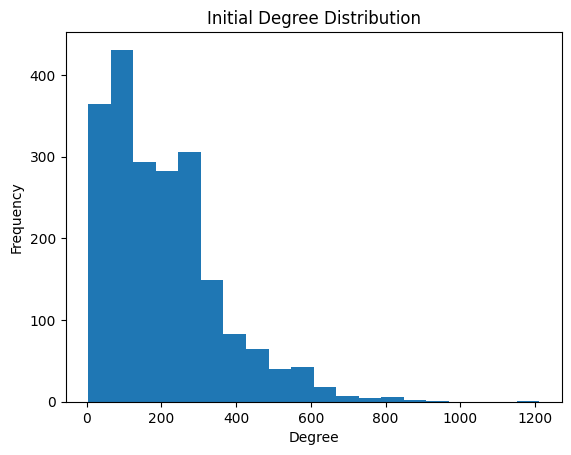

Validation passed: Graph pipeline works


In [25]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

G = nx.Graph()

for imp in behaviors_df['impressions'].head(200):

    if not isinstance(imp, str) or len(imp.strip()) == 0:
        continue

    items = [x.split('-')[0] for x in imp.split() if '-' in x]
    items = list(set(items))

    for i in range(len(items)):
        for j in range(i+1, len(items)):
            G.add_edge(items[i], items[j])

degrees = np.array([d for _, d in G.degree()])

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

# -------- Validation Tests --------
assert G.number_of_nodes() > 0, "Empty graph"
assert np.std(degrees) > 0, "No variation in degree"

# -------- Lightweight Plot --------
plt.figure()
plt.hist(degrees, bins=20)
plt.title("Initial Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.show()

print("Validation passed: Graph pipeline works")

**Interpretation:**  

- The graph is successfully constructed with 2,096 nodes and over 214K edges, confirming correct pipeline execution.  
- The degree distribution shows a right-skewed pattern, with most nodes having moderate connectivity and a few nodes exhibiting higher degrees.  

---

### RQ3: Initial Run – Text Pipeline

**Goal:**  
Verify TF-IDF and LDA execution and output validity.

LDA shape: (3, 500)


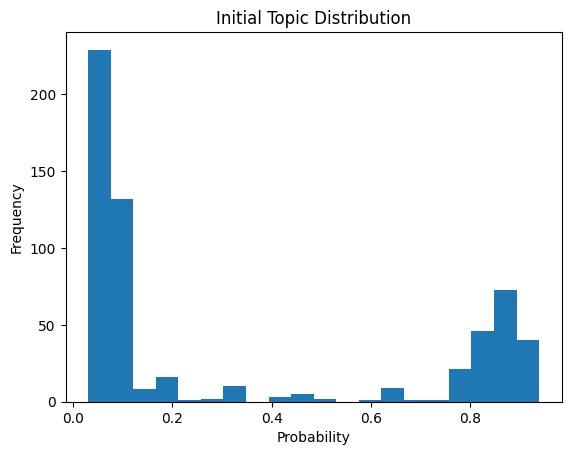

Validation passed: Text pipeline works


In [26]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import numpy as np
import matplotlib.pyplot as plt

titles = news_df['title'].fillna("").head(200)

vectorizer = CountVectorizer(max_features=500, stop_words='english')
X = vectorizer.fit_transform(titles)

lda = LatentDirichletAllocation(n_components=3, random_state=42)
lda.fit(X)

topic_dist = lda.transform(X)

print("LDA shape:", lda.components_.shape)

# -------- Validation Tests --------
assert topic_dist.shape[0] == X.shape[0], "Mismatch in documents"
assert np.std(topic_dist) > 0, "No topic variation"

# -------- Lightweight Plot --------
plt.figure()
plt.hist(topic_dist.flatten(), bins=20)
plt.title("Initial Topic Distribution")
plt.xlabel("Probability")
plt.ylabel("Frequency")
plt.show()

print("Validation passed: Text pipeline works")

**Interpretation:**  

- The LDA model successfully produces topic components (3 x 500), confirming correct execution of the text processing pipeline.  
- The topic distribution shows most documents having low probabilities across many topics, with some higher peaks, indicating soft topic assignments and variation across documents.  

---

### Initial Run – Learning-to-Rank

**Goal:**  
Verify ranking model produces valid outputs.

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import numpy as np

X = np.random.rand(200, 1)
y = np.random.randint(0, 2, 200)

model = LogisticRegression()
model.fit(X, y)

preds = model.predict_proba(X)[:, 1]

# -------- Validation Tests --------
assert len(np.unique(y)) == 2, "Single class issue"
assert np.std(preds) > 0, "Constant predictions"

auc = roc_auc_score(y, preds)

print("AUC:", auc)
print("Prediction std:", np.std(preds))

print("Validation passed: Ranking pipeline works")

AUC: 0.5303530353035303
Prediction std: 0.022775238576524123
Validation passed: Ranking pipeline works


**Interpretation:**  

- The model successfully produces non-constant predictions with measurable variance (0.023), confirming correct pipeline execution.  
- The AUC (0.53), slightly above random, indicates that the model can capture weak signal even with simple features.  


---
---

### **Updating GitHub Repo -**

The code notebook has been committed to GitHub Repo - https://github.com/akashmoses97/news-rec-atlas under notebooks folder as '02_research_question_formation.ipynb' and accordingly updated the README.md

---
---

On my honor, I declare the following resources:

---

### 1. Collaborators:
- None

---

### 2. Web Sources:
- https://msnews.github.io/  
  - Official MIND dataset source used for understanding dataset structure and fields  

- https://scikit-learn.org/  
  - Referenced for implementation details of TF-IDF, Logistic Regression, and LDA  

- https://rasbt.github.io/mlxtend/  
  - Referenced for FP-Growth and TransactionEncoder usage  

---

### 3. AI Tools

- ChatGPT:

  - **Step 1 (Project Scope & EDA Refinement):**  
    Used ChatGPT to refine the project scope, ensure alignment with Checkpoint-1 EDA, and structure dataset description and key findings clearly.

  - **Step 2 (Research Question Formation):**  
    Prompted ChatGPT to iteratively refine research questions from project checkpoint-1 to ensure they align with course techniques and external methods, and to improve clarity and real-world relevance.

  - **Step 3 (EDA for RQ Motivation & Exploration):**  
    Used ChatGPT to design targeted EDA code, incorporate real-world data handling, and structure insights that helped to get well-motivated research questions.

  - **Step 4 (Feasibility Checks & Validation):**  
    Used ChatGPT to design feasibility experiments for each method, optimize implementations (e.g., FP-Growth scaling), and include meaningful validation tests.

  - **Step 5 (Methodological Planning & Metrics):**  
    Used ChatGPT to structure method-to-RQ mapping, refine evaluation metrics (pattern-level and ranking-level), and ensure alignment with assignment requirements.

- Although ChatGPT was used for guidance and structuring, all content was carefully reviewed, validated, brain-stormed, coherently strucutured and refined to ensure correctness, relevance, and alignment with the project requirements.
---

### 4. Citations

- Wu, C., Wu, F., An, M., Huang, J., Huang, Y., & Xie, X. (2020).  
  *MIND: A Large-Scale Dataset for News Recommendation.*  
  Proceedings of the 58th Annual Meeting of the Association for Computational Linguistics (ACL).

---